In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


In [4]:
import zipfile
import io

# Get the content of the uploaded zip file
# Assuming 'archive (8).zip' is the key in the uploaded dictionary
zip_file_name = list(uploaded.keys())[0]
zip_file_content = uploaded[zip_file_name]

# Open the zip file in memory
with zipfile.ZipFile(io.BytesIO(zip_file_content), 'r') as z:
    # List files in the zip archive
    file_list = z.namelist()
    csv_files = [f for f in file_list if f.endswith('.csv')]

    if csv_files:
        # Assuming the first CSV file is the one we want to read
        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f)
        print(f"Successfully loaded '{csv_files[0]}' into DataFrame 'df'.")
    else:
        print("No CSV files found in the uploaded zip archive.")
        # If no CSV is found, df will remain undefined.

# Now that df is defined, call head()
df.head()

Successfully loaded 'titanic_survival_ml_ready_2500_rows.csv' into DataFrame 'df'.


,PassengerId,Survived,Pclass,Sex,Age,AgeGroup,SibSp,Parch,FamilySize,IsAlone,Fare,FarePerPerson,Embarked
0,1,0,2,1,21.6,2,1,0,2,0,13.35,6.68,0
1,2,1,3,1,0.5,0,0,0,1,1,18.38,18.38,2
2,3,0,3,0,24.2,2,1,1,3,0,15.03,5.01,0
3,4,0,3,1,42.8,2,0,0,1,1,21.70,21.70,2
4,5,0,1,0,37.5,2,0,0,1,1,91.02,91.02,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    2500 non-null   int64  
 1   Survived       2500 non-null   int64  
 2   Pclass         2500 non-null   int64  
 3   Sex            2500 non-null   int64  
 4   Age            2500 non-null   float64
 5   AgeGroup       2500 non-null   int64  
 6   SibSp          2500 non-null   int64  
 7   Parch          2500 non-null   int64  
 8   FamilySize     2500 non-null   int64  
 9   IsAlone        2500 non-null   int64  
 10  Fare           2500 non-null   float64
 11  FarePerPerson  2500 non-null   float64
 12  Embarked       2500 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 254.0 KB


In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns")
print(num_cols)

print()

print("Categorical Columns")
print(cat_cols)

Numerical Columns
Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'AgeGroup', 'SibSp',
       'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson', 'Embarked'],
      dtype='object')

Categorical Columns
Index([], dtype='object')


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
AgeGroup,0
SibSp,0
Parch,0
FamilySize,0
IsAlone,0


In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
AgeGroup,0
SibSp,0
Parch,0
FamilySize,0
IsAlone,0


In [11]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df["Fare"]<lower) | (df["Fare"]>upper)]

print("Number of Outliers:",len(outliers))

Number of Outliers: 378


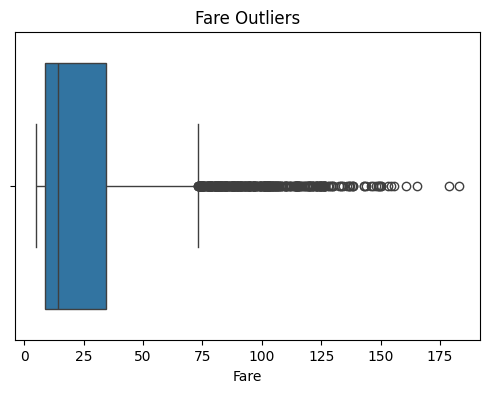

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

In [13]:
print("Duplicates:",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After Removal:",df.duplicated().sum())

Duplicates: 0
Duplicates After Removal: 0


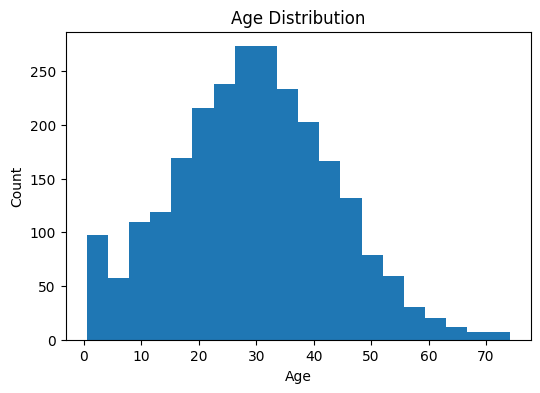

In [14]:
plt.figure(figsize=(6,4))

plt.hist(df["Age"],bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

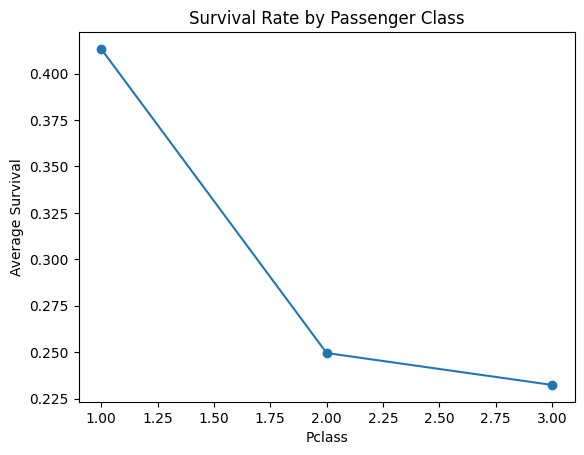

In [15]:
df.groupby("Pclass")["Survived"].mean().plot(marker='o')

plt.title("Survival Rate by Passenger Class")

plt.ylabel("Average Survival")

plt.show()

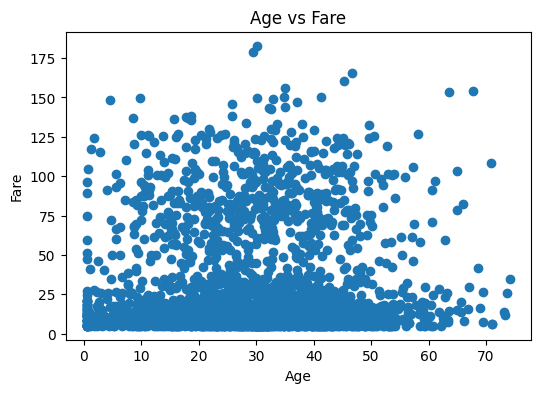

In [16]:
plt.figure(figsize=(6,4))

plt.scatter(df["Age"],df["Fare"])

plt.xlabel("Age")

plt.ylabel("Fare")

plt.title("Age vs Fare")

plt.show()

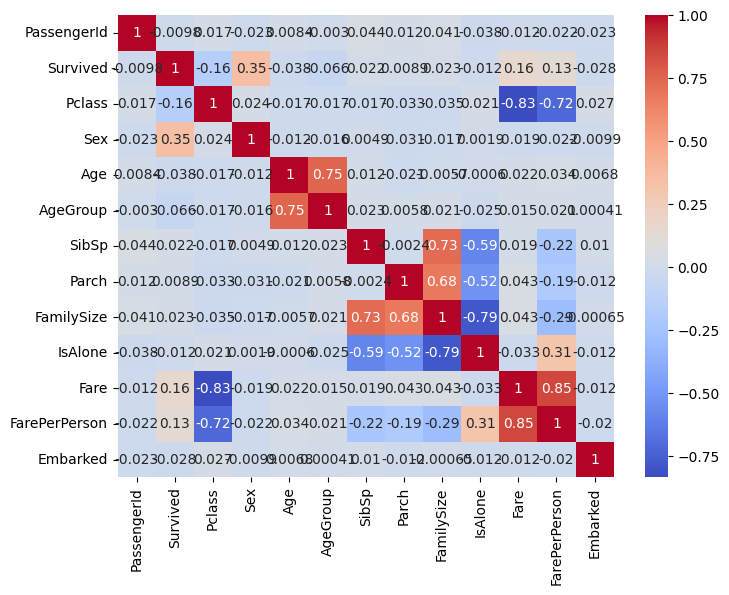

In [17]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")

plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

df["Embarked"] = le.fit_transform(df["Embarked"])

In [21]:
df = df.drop(["PassengerId"],axis=1)

df.head()

,Survived,Pclass,Sex,Age,AgeGroup,SibSp,Parch,FamilySize,IsAlone,Fare,FarePerPerson,Embarked
0,0,2,1,21.6,2,1,0,2,0,13.35,6.68,0
1,1,3,1,0.5,0,0,0,1,1,18.38,18.38,2
2,0,3,0,24.2,2,1,1,3,0,15.03,5.01,0
3,0,3,1,42.8,2,0,0,1,1,21.70,21.70,2
4,0,1,0,37.5,2,0,0,1,1,91.02,91.02,2


In [22]:
X = df.drop("Survived",axis=1)

y = df["Survived"]

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred1 = lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred1))

Accuracy: 0.748


In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred2 = dt.predict(X_test)

result = pd.DataFrame({
    "Model":["Logistic Regression", "Decision Tree"],
    "Accuracy":[accuracy_score(y_test,pred1),
                accuracy_score(y_test,pred2)]
})

result

,Model,Accuracy
0,Logistic Regression,0.748
1,Decision Tree,0.662


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred1))

              precision    recall  f1-score   support

           0       0.78      0.92      0.84       366
           1       0.56      0.28      0.38       134

    accuracy                           0.75       500
   macro avg       0.67      0.60      0.61       500
weighted avg       0.72      0.75      0.72       500

